<h1> <b>Implementing a Forward Pass using Numpy </b> </h1>


We’ll use:<br><br>

- Input dimension: 2 <br>
- Hidden layer: 3 neurons <br>
- Output layer: 1 neuron <br>
- Activation: ReLU

In [49]:
import numpy as np

#input sample
x = np.array([[1.5 , -0.5]]) #shape 1,2

#initialization
np.random.seed(42)
W1 = np.random.randn(2,3)
b1 = np.random.randn(1,3)
W2 = np.random.randn(3,1)
b2 = np.random.randn(1,1)

In [50]:
# ReLU activation
def relu(z):
    return np.maximum(0, z)

# Sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))



In [51]:
# Forward pass
z1 = np.dot(x, W1) + b1 # (1, 3)
h = relu(z1) # (1, 3)
y_hat = np.dot(h, W2) + b2 # (1, 1)


print("Hidden activation h:", h)
print("Predicted y_hat:", y_hat)

Hidden activation h: [[1.56276912 0.67711496 0.6191269 ]]
Predicted y_hat: [[0.48772548]]


<b>This is a clean forward computation through:</b>

<b>A hidden layer with nonlinear activation</b>
<b>A final linear output neuron</b>

<h2> <b>Implementing Backward Pass in NumPy </b> </h2>

In [52]:
import numpy as np

np.random.seed(42)

x = np.array([[2.0, -1.0]])   # single sample input (1, 2)
y = np.array([[1.0]])         # binary target

In [53]:
# Weights & biases
W1 = np.random.randn(2, 3) # (input_dim, hidden_dim)
b1 = np.random.randn(1, 3)

W2 = np.random.randn(3, 1) # (hidden_dim, output_dim)
b2 = np.random.randn(1, 1)

In [54]:
# ReLU and its derivative
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

In [55]:
# Forward pass
z1 = x @ W1 + b1 # Hidden linear
h = relu(z1)# Hidden activation
y_hat = h @ W2 + b2 # Output (no activation yet)

In [56]:
# Compute loss (MSE)
loss = 0.5 * (y_hat - y)**2

print("Prediction:", y_hat)
print("Loss:", loss)


Prediction: [[-0.018258]]
Loss: [[0.51842468]]


<b>Now Let’s Add Backward Pass</b>

In [57]:
# Backward pass
# Derivative of loss w.r.t. prediction
dL_dyhat = y_hat - y     # shape (1, 1)

# Gradients for output layer
dL_dW2 = h.T @ dL_dyhat  # (3, 1)
dL_db2 = dL_dyhat        # (1, 1)

In [58]:
# Gradient flowing into hidden layer
dL_dh = dL_dyhat @ W2.T # shape (1, 3)
dL_dz1 = dL_dh * relu_derivative(z1) # shape (1, 3)

# Gradients for first layer
dL_dW1 = x.T @ dL_dz1 # (2, 3)
dL_db1 = dL_dz1 # (1, 3)

<b>Gradient Check</b>

Let’s print the gradients to verify the shapes and values:

In [59]:
print("Grad W2:", dL_dW2)
print("Grad b2:", dL_db2)
print("Grad W1:", dL_dW1)
print("Grad b1:", dL_db1)

Grad W2: [[-1.06877507]
 [-0.73829764]
 [-1.07939385]]
Grad b2: [[-1.018258]]
Grad W1: [[-1.10493221  0.94375755  0.94846609]
 [ 0.5524661  -0.47187877 -0.47423305]]
Grad b1: [[-0.5524661   0.47187877  0.47423305]]


Parameter Update

We’ll now do one step of SGD (Stochastic Gradient Descent):

In [60]:
# Learning rate
lr = 0.01

# Gradient descent update
W2 -= lr * dL_dW2
b2 -= lr * dL_db2
W1 -= lr * dL_dW1
b1 -= lr * dL_db1

<h> <b>Manual Training Over Epochs (Stochastic Gradient Descent) </b> </h2>
<br>
Manual Training Loop

In [61]:
# Initialize weights and biases again (reset)
np.random.seed(42)

x = np.array([[1.0, -1.0]])
y = np.array([[1.0]])

In [62]:
W1 = np.random.randn(2, 3)
b1 = np.random.randn(1, 3)
W2 = np.random.randn(3, 1)
b2 = np.random.randn(1, 1)

# Hyperparameters
lr = 0.1
epochs = 10
losses = []

In [63]:
# Training loop
for epoch in range(epochs):
    #  Forward pass 
    z1 = x @ W1 + b1
    h = relu(z1)
    y_hat = h @ W2 + b2
    loss = 0.5 * (y_hat - y)**2
    losses.append(loss.item())

    # Backward pass
    dL_dyhat = y_hat - y
    dL_dW2 = h.T @ dL_dyhat
    dL_db2 = dL_dyhat

    dL_dh = dL_dyhat @ W2.T
    dL_dz1 = dL_dh * relu_derivative(z1)
    dL_dW1 = x.T @ dL_dz1
    dL_db1 = dL_dz1
    
    # Parameter update
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

Epoch 1: Loss = 0.5514
Epoch 2: Loss = 0.1787
Epoch 3: Loss = 0.0611
Epoch 4: Loss = 0.0203
Epoch 5: Loss = 0.0065
Epoch 6: Loss = 0.0020
Epoch 7: Loss = 0.0006
Epoch 8: Loss = 0.0002
Epoch 9: Loss = 0.0001
Epoch 10: Loss = 0.0000


<h1> <b> Visualizing Training Loss Curve </b> </h1> <br>
Tracking the loss over epochs helps us answer key questions:

Is the model learning?
Is the learning stabilizing?
Is it getting stuck or diverging?
Let’s visualize the loss we stored during training.


**Plot the Loss Over Epochs**


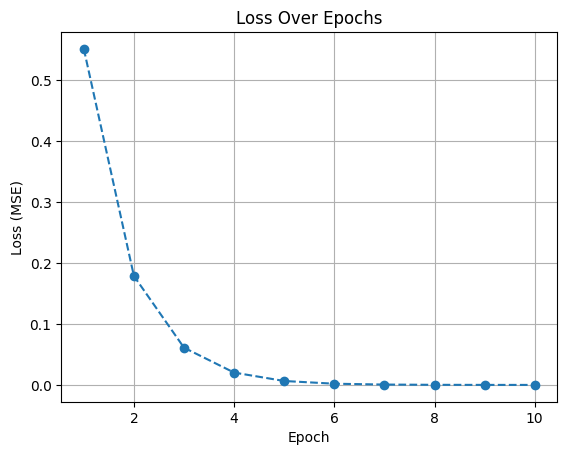

In [64]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='--')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()

<h1> <b> Visualizing Learning on a Single Point </b> </h1>
Now that we’ve trained our small neural network using manual backpropagation,
let’s visualize how the model’s prediction evolves over training.




Plot Output Prediction over Epochs

In [65]:
# Assuming we stored model predictions per epoch (let's simulate it now)

predictions = []

# Re-run training loop (same as Section 5) but store predictions

# Reset weights
np.random.seed(42)
W1 = np.random.randn(2, 3)
b1 = np.random.randn(1, 3)
W2 = np.random.randn(3, 1)
b2 = np.random.randn(1, 1)


In [66]:
# Hyperparameters
lr = 0.1
epochs = 10
losses = []
predictions = []

In [67]:
# Input and target
x = np.array([[2.0, -1.0]])
y = np.array([[1.0]])

In [68]:
for epoch in range(epochs):
    # Forward pass
    z1 = x @ W1 + b1
    h = relu(z1)
    y_hat = h @ W2 + b2
    loss = 0.5 * (y_hat - y)**2

    losses.append(loss.item())
    predictions.append(y_hat.item())

    # Backward pass
    dL_dyhat = y_hat - y
    dL_dW2 = h.T @ dL_dyhat
    dL_db2 = dL_dyhat

    dL_dh = dL_dyhat @ W2.T
    dL_dz1 = dL_dh * relu_derivative(z1)
    dL_dW1 = x.T @ dL_dz1
    dL_db1 = dL_dz1

    # Update
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

Output Trajectory Plot

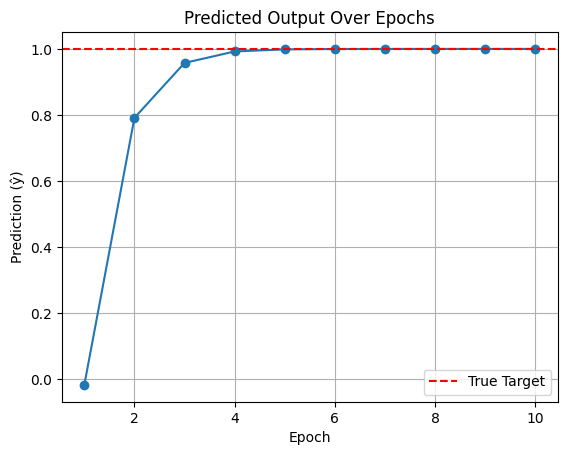

In [69]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), predictions, marker='o')
plt.title("Predicted Output Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Prediction (ŷ)")
plt.grid(True)
plt.axhline(y=1.0, color='r', linestyle='--', label='True Target')
plt.legend()
plt.show()

<b>The curve shows how quickly 
 moves toward the correct value <br>
A steady, smooth rise is a good sign that shows that the model is learning effectively <br>
If the curve stagnates or oscillates, it could mean:<br>
- The learning rate is too high or too low<br>
- The network capacity is insufficient<br>
- There are vanishing gradients (in deeper nets)</b>
